# Problem 1: Selected-one-lag RF / XGBoost Modeling

This notebook trains the final selected-one-lag prediction models for output water turbidity (`NTU`).

Main workflow:

```text
selected_one_lag_model_data.xlsx
→ F/RIDE missing values filled with 0
→ time-based train/test split
→ train-only Z-score standardization
→ median imputation
→ Random Forest / XGBoost training
→ model evaluation
→ target-date prediction
→ visualization
```

Important modeling rule:

```text
target_NTU is not standardized.
```

Therefore, MAE, RMSE, and predicted NTU values remain in the original NTU unit.


## Notebook setup and package imports

In [45]:
# ============================================================
# Train Selected-one-lag RF / XGBoost Models for Problem 1
# ============================================================
# Input:
#   data/selected_one_lag_model_data.xlsx
#
# Core modeling form:
#   NTU_t = f(one selected lag feature for each variable)
#
# This script:
# 1. Reads selected_one_lag_model_data.xlsx
# 2. Fills missing F/RIDE lag feature values with 0
# 3. Excludes target OP_DATE rows from model training
# 4. Uses time-order split for evaluation
# 5. Standardizes input features using training-period statistics only
# 6. Uses median imputation for remaining missing input values
# 7. Trains Random Forest and XGBoost
# 8. Outputs model metrics, predictions, feature importance, and target-date predictions
#
# Important:
#   target_NTU is NOT standardized.
#   Therefore MAE / RMSE / predictions remain in original NTU units.
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
from pathlib import Path

from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

import matplotlib.pyplot as plt
from sklearn.preprocessing import SplineTransformer
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline

try:
    from xgboost import XGBRegressor
    XGBOOST_AVAILABLE = True
except Exception as e:
    XGBOOST_AVAILABLE = False
    print("Warning: xgboost is not available. Only Random Forest will be trained.")
    print("XGBoost import error:", e)

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)

## 0. Modeling settings

Define the target column, target OP_DATEs, train/test ratio, and whether F/RIDE missing values should be filled with 0.

In [46]:
# ============================================================
# 0. Settings
# ============================================================

INPUT_FILENAME = "selected_one_lag_model_data.xlsx"

TARGET_COL = "target_NTU"
TIME_COL = "DATETIME"
OP_DATE_COL = "OP_DATE"

TARGET_OP_DATES = [
    "2026-02-01",
    "2026-02-10",
    "2026-02-20",
]

TRAIN_RATIO = 0.80
RANDOM_STATE = 42

# Fill F/RIDE lag feature missing values with 0 before standardization.
FILL_FRIDE_MISSING_WITH_ZERO = True

# If True, final model for target-date prediction is refit on all observed non-target-date rows.
REFIT_FINAL_MODEL_ON_ALL_AVAILABLE_TRAINING_DATA = True

## 1. Locate input file

In [47]:
# ============================================================
# 1. Locate input file automatically
# ============================================================

def find_input_excel(filename=INPUT_FILENAME):
    """Search common project paths for selected_one_lag_model_data.xlsx."""
    cwd = Path.cwd().resolve()
    candidate_paths = []

    search_roots = [cwd] + list(cwd.parents)

    for root in search_roots:
        candidate_paths.extend([
            root / "data" / filename,
            root / "codes" / "data" / filename,
            root / "2026-Asia-Pacific-cup" / "data" / filename,
            root / "2026-Asia-Pacific-cup" / "codes" / "data" / filename,
            root / "2026-Asia-Pasific-cup" / "data" / filename,
            root / "2026-Asia-Pasific-cup" / "codes" / "data" / filename,
            root / filename,
        ])

    seen = set()
    unique_candidates = []
    for p in candidate_paths:
        p = p.resolve()
        if p not in seen:
            seen.add(p)
            unique_candidates.append(p)

    for p in unique_candidates:
        if p.exists():
            return p

    # Fallback: recursive search under current directory
    for p in cwd.rglob(filename):
        if p.name == filename:
            return p.resolve()

    raise FileNotFoundError(
        f"Cannot find {filename}. Current working directory: {cwd}"
    )


DATA_PATH = find_input_excel()
DATA_DIR = DATA_PATH.parent

if DATA_DIR.name == "data":
    PROJECT_DIR = DATA_DIR.parent
else:
    PROJECT_DIR = DATA_DIR

OUTPUT_DIR = PROJECT_DIR / "outputs" / "problem1"
MODEL_DIR = OUTPUT_DIR / "models"
FIG_DIR = OUTPUT_DIR / "figures"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("Current working directory:", Path.cwd().resolve())
print("Using input file:", DATA_PATH)
print("Data directory:", DATA_DIR)
print("Output directory:", OUTPUT_DIR)
print("Model directory:", MODEL_DIR)
print("Figure directory:", FIG_DIR)

Current working directory: E:\桌面\亚太杯\2026-Asia-Pasific-cup\codes
Using input file: E:\桌面\亚太杯\2026-Asia-Pasific-cup\data\selected_one_lag_model_data.xlsx
Data directory: E:\桌面\亚太杯\2026-Asia-Pasific-cup\data
Output directory: E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem1
Model directory: E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem1\models
Figure directory: E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem1\figures


## 2. Read and validate selected-one-lag data

In [48]:
# ============================================================
# 2. Read and validate data
# ============================================================

df = pd.read_excel(DATA_PATH)

print("\nOriginal selected-one-lag data shape:", df.shape)
print("Columns:")
print(df.columns.tolist())

required_cols = [TIME_COL, OP_DATE_COL, TARGET_COL]
missing_required = [col for col in required_cols if col not in df.columns]
if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

df[TIME_COL] = pd.to_datetime(df[TIME_COL], errors="coerce")
df[OP_DATE_COL] = pd.to_datetime(df[OP_DATE_COL], errors="coerce").dt.date
df[TARGET_COL] = pd.to_numeric(df[TARGET_COL], errors="coerce")

df = df.sort_values(TIME_COL).reset_index(drop=True)

feature_cols = [
    col for col in df.columns
    if col not in [TIME_COL, OP_DATE_COL, TARGET_COL]
]

if len(feature_cols) == 0:
    raise ValueError("No feature columns found. Please check selected_one_lag_model_data.xlsx.")

for col in feature_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print("\nFeature columns:")
for col in feature_cols:
    print(" -", col)


Original selected-one-lag data shape: (5460, 12)
Columns:
['DATETIME', 'OP_DATE', 'target_NTU', 'FILT. NTU_lag1_z', 'CLR_lag0_z', 'R/W FLOW_lag1_z', 'T/W FLOW_lag1_z', 'RIVER LEVEL_lag0_z', 'R/W NTU_lag0_z', 'CL2_lag0_z', 'ALUM_lag1_z', 'F/RIDE_lag6_z']

Feature columns:
 - FILT. NTU_lag1_z
 - CLR_lag0_z
 - R/W FLOW_lag1_z
 - T/W FLOW_lag1_z
 - RIVER LEVEL_lag0_z
 - R/W NTU_lag0_z
 - CL2_lag0_z
 - ALUM_lag1_z
 - F/RIDE_lag6_z


## 3. Fill F/RIDE missing values with 0

F/RIDE has many missing values. Here, missing values in F/RIDE-related lag features are filled with 0 before standardization.

In [49]:
# ============================================================
# 3. Fill missing F/RIDE feature values with 0
# ============================================================

fride_cols = [col for col in feature_cols if "F/RIDE" in col]

fride_fill_records = []

if FILL_FRIDE_MISSING_WITH_ZERO and len(fride_cols) > 0:
    print("\nFilling missing F/RIDE lag feature values with 0:")
    for col in fride_cols:
        missing_before = df[col].isna().sum()
        df[col] = df[col].fillna(0)
        missing_after = df[col].isna().sum()
        fride_fill_records.append({
            "column": col,
            "missing_before": missing_before,
            "missing_after": missing_after,
            "fill_value": 0,
        })
        print(f" - {col}: missing before = {missing_before}, after = {missing_after}")
else:
    print("\nNo F/RIDE column found or filling disabled.")

fride_fill_df = pd.DataFrame(fride_fill_records)


Filling missing F/RIDE lag feature values with 0:
 - F/RIDE_lag6_z: missing before = 6, after = 0


## 4. Define target dates and training data

In [50]:
# ============================================================
# 4. Mark target dates and define observed training/evaluation data
# ============================================================

target_op_dates = [pd.to_datetime(d).date() for d in TARGET_OP_DATES]
df["is_target_op_date"] = df[OP_DATE_COL].isin(target_op_dates)

# Rows with observed target and not target OP_DATE are available for model evaluation/training.
observed_non_target_df = df[
    df[TARGET_COL].notna() & (~df["is_target_op_date"])
].copy()

target_date_df = df[df["is_target_op_date"]].copy()

print("\nRows total:", len(df))
print("Rows with observed target_NTU:", df[TARGET_COL].notna().sum())
print("Rows excluded as target OP_DATE:", df["is_target_op_date"].sum())
print("Rows available for training/evaluation:", len(observed_non_target_df))
print("Rows for target-date prediction:", len(target_date_df))

if len(observed_non_target_df) < 50:
    raise ValueError("Too few observed non-target rows for training/evaluation.")


Rows total: 5460
Rows with observed target_NTU: 5124
Rows excluded as target OP_DATE: 36
Rows available for training/evaluation: 5124
Rows for target-date prediction: 36


## 5. Time-based train/test split

The data are split by chronological order rather than random sampling, which is more appropriate for time-series prediction.

In [51]:
# ============================================================
# 5. Time-based train/test split
# ============================================================

split_idx = int(len(observed_non_target_df) * TRAIN_RATIO)

train_df = observed_non_target_df.iloc[:split_idx].copy()
test_df = observed_non_target_df.iloc[split_idx:].copy()

print("\nTrain/test split:")
print("Train rows:", len(train_df))
print("Test rows:", len(test_df))
print("Train time range:", train_df[TIME_COL].min(), "to", train_df[TIME_COL].max())
print("Test time range:", test_df[TIME_COL].min(), "to", test_df[TIME_COL].max())

X_train_raw = train_df[feature_cols].copy()
y_train = train_df[TARGET_COL].copy()

X_test_raw = test_df[feature_cols].copy()
y_test = test_df[TARGET_COL].copy()


Train/test split:
Train rows: 4099
Test rows: 1025
Train time range: 2025-01-01 07:00:00 to 2025-12-08 19:00:00
Test time range: 2025-12-08 21:00:00 to 2026-04-01 05:00:00


## 6. Standardization and imputation

Input features are standardized using training-period mean and standard deviation only. Remaining missing values are imputed using the training median.

In [52]:
# ============================================================
# 6. Standardization and imputation helpers
# ============================================================

def fit_standardizer(X_train):
    """Fit train-only mean/std for each feature."""
    records = []
    means = {}
    stds = {}

    for col in X_train.columns:
        mean_value = X_train[col].mean(skipna=True)
        std_value = X_train[col].std(skipna=True)

        if pd.isna(std_value) or std_value == 0:
            std_value_safe = 1.0
            status = "std_zero_or_nan_set_to_1"
        else:
            std_value_safe = std_value
            status = "success"

        means[col] = mean_value
        stds[col] = std_value_safe

        records.append({
            "feature": col,
            "train_mean": mean_value,
            "train_std": std_value,
            "std_used": std_value_safe,
            "status": status,
        })

    info_df = pd.DataFrame(records)
    return means, stds, info_df


def transform_standardize(X, means, stds):
    """Apply train-only standardization."""
    X_z = X.copy()
    for col in X.columns:
        X_z[col] = (X[col] - means[col]) / stds[col]
    return X_z


def prepare_train_test(X_train_raw, X_test_raw):
    """
    Standardize using train-only statistics,
    then impute remaining missing values using train-only median.
    """
    means, stds, standardization_info = fit_standardizer(X_train_raw)

    X_train_z = transform_standardize(X_train_raw, means, stds)
    X_test_z = transform_standardize(X_test_raw, means, stds)

    imputer = SimpleImputer(strategy="median")
    X_train_ready = imputer.fit_transform(X_train_z)
    X_test_ready = imputer.transform(X_test_z)

    return X_train_ready, X_test_ready, means, stds, imputer, standardization_info, X_train_z, X_test_z


X_train_ready, X_test_ready, eval_means, eval_stds, eval_imputer, eval_standardization_info_df, X_train_z_df, X_test_z_df = prepare_train_test(
    X_train_raw,
    X_test_raw
)

print("\nStandardization and imputation completed.")
print("X_train_ready shape:", X_train_ready.shape)
print("X_test_ready shape:", X_test_ready.shape)


Standardization and imputation completed.
X_train_ready shape: (4099, 9)
X_test_ready shape: (1025, 9)


## 7. Train Random Forest and XGBoost

Train Random Forest and XGBoost models and evaluate them using MAE, RMSE, R², and MAPE.

In [53]:
# ============================================================
# 7. Define and train models
# ============================================================

models = {}

rf_model = RandomForestRegressor(
    n_estimators=600,
    max_depth=None,
    min_samples_split=4,
    min_samples_leaf=2,
    max_features="sqrt",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

models["Selected-one-lag Random Forest"] = rf_model

# ============================================================
# GAM-like spline additive model
# ============================================================

gam_model = make_pipeline(
    SplineTransformer(
        n_knots=6,
        degree=3,
        include_bias=False
    ),
    Ridge(alpha=1.0)
)

models["Selected-one-lag GAM"] = gam_model

if XGBOOST_AVAILABLE:
    xgb_model = XGBRegressor(
        n_estimators=800,
        learning_rate=0.03,
        max_depth=4,
        min_child_weight=2,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_lambda=2.0,
        reg_alpha=0.0,
        objective="reg:squarederror",
        eval_metric="rmse",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    models["Selected-one-lag XGBoost"] = xgb_model


def regression_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    # Avoid division by zero in MAPE.
    y_true_arr = np.asarray(y_true)
    y_pred_arr = np.asarray(y_pred)
    nonzero_mask = y_true_arr != 0
    if nonzero_mask.sum() > 0:
        mape = np.mean(np.abs((y_true_arr[nonzero_mask] - y_pred_arr[nonzero_mask]) / y_true_arr[nonzero_mask])) * 100
    else:
        mape = np.nan

    return {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "MAPE_percent": mape,
    }


results_records = []
test_prediction_df = test_df[[TIME_COL, OP_DATE_COL, TARGET_COL]].copy()
test_prediction_df = test_prediction_df.rename(columns={TARGET_COL: "actual_NTU"})

feature_importance_tables = {}

print("\nTraining models...")

for model_name, model in models.items():
    model.fit(X_train_ready, y_train)
    y_pred = model.predict(X_test_ready)

    metrics = regression_metrics(y_test, y_pred)

    results_records.append({
        "model": model_name,
        "train_rows": len(train_df),
        "test_rows": len(test_df),
        "feature_count": len(feature_cols),
        **metrics,
    })

    pred_col = model_name.replace(" ", "_").replace("/", "_") + "_pred"
    test_prediction_df[pred_col] = y_pred

    if hasattr(model, "feature_importances_"):
        fi_df = pd.DataFrame({
            "feature": feature_cols,
            "importance": model.feature_importances_,
            "model": model_name,
        }).sort_values("importance", ascending=False)
        feature_importance_tables[model_name] = fi_df

    # Save evaluation-stage fitted model
    model_path = MODEL_DIR / (pred_col + "_evaluation_model.joblib")
    joblib.dump({
        "model": model,
        "feature_cols": feature_cols,
        "means": eval_means,
        "stds": eval_stds,
        "imputer": eval_imputer,
        "target_col": TARGET_COL,
        "note": "Evaluation model fitted on first 80% observed non-target rows."
    }, model_path)

    print(f" - Finished {model_name}")

results_df = pd.DataFrame(results_records).sort_values("RMSE", ascending=True)

print("\nModel evaluation results:")
print(results_df.to_string(index=False))


Training models...
 - Finished Selected-one-lag Random Forest
 - Finished Selected-one-lag GAM
 - Finished Selected-one-lag XGBoost

Model evaluation results:
                         model  train_rows  test_rows  feature_count      MAE     RMSE        R2  MAPE_percent
Selected-one-lag Random Forest        4099       1025              9 0.175487 0.268848  0.075639     51.657555
          Selected-one-lag GAM        4099       1025              9 0.204449 0.317641 -0.290333     53.777902
      Selected-one-lag XGBoost        4099       1025              9 0.193322 0.339486 -0.473911     50.571126


### 广义加性模型

除树模型外，本文进一步引入广义加性模型作为可解释的非线性对比模型。对于 selected-one-lag 特征，首先通过三次样条基函数进行非线性展开，再使用岭回归估计各变量的加性影响。模型形式为：

$$
NTU_t = \beta_0 + \sum_{j=1}^{p} f_j(x_{j,t-k_j}) + \epsilon_t
$$

其中，$f_j(\cdot)$ 表示第 $j$ 个滞后特征对当前 NTU 的平滑非线性影响。与 Random Forest 和 XGBoost 相比，GAM 的结构更受约束，因此可作为一种兼具非线性拟合能力和可解释性的对比模型。

## 8. Select best model

In [54]:
# ============================================================
# 8. Select best model by test RMSE
# ============================================================

best_model_name = results_df.iloc[0]["model"]
print("\nBest model by test RMSE:", best_model_name)


Best model by test RMSE: Selected-one-lag Random Forest


## 9. Refit final models and predict target dates

After evaluation, final models are refitted on all observed non-target rows and used to predict the specified target dates.

In [55]:
# ============================================================
# 9. Refit final models on all observed non-target rows for target-date prediction
# ============================================================

final_train_df = observed_non_target_df.copy()

X_final_train_raw = final_train_df[feature_cols].copy()
y_final_train = final_train_df[TARGET_COL].copy()

# Fit final preprocessing on all observed non-target rows.
final_means, final_stds, final_standardization_info_df = fit_standardizer(X_final_train_raw)
X_final_train_z = transform_standardize(X_final_train_raw, final_means, final_stds)

final_imputer = SimpleImputer(strategy="median")
X_final_train_ready = final_imputer.fit_transform(X_final_train_z)

# Prepare target-date rows.
X_target_raw = target_date_df[feature_cols].copy()
X_target_z = transform_standardize(X_target_raw, final_means, final_stds)
X_target_ready = final_imputer.transform(X_target_z)

target_predictions_df = target_date_df[[TIME_COL, OP_DATE_COL, TARGET_COL]].copy()
target_predictions_df = target_predictions_df.rename(columns={TARGET_COL: "actual_NTU_if_available"})

final_model_objects = {}

for model_name, eval_model in models.items():
    # Create a fresh model with same parameters.
    if model_name == "Selected-one-lag Random Forest":
        final_model = RandomForestRegressor(
            n_estimators=600,
            max_depth=None,
            min_samples_split=4,
            min_samples_leaf=2,
            max_features="sqrt",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
    elif model_name == "Selected-one-lag XGBoost" and XGBOOST_AVAILABLE:
        final_model = XGBRegressor(
            n_estimators=800,
            learning_rate=0.03,
            max_depth=4,
            min_child_weight=2,
            subsample=0.85,
            colsample_bytree=0.85,
            reg_lambda=2.0,
            reg_alpha=0.0,
            objective="reg:squarederror",
            eval_metric="rmse",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
    else:
        continue

    final_model.fit(X_final_train_ready, y_final_train)

    pred_col = model_name.replace(" ", "_").replace("/", "_") + "_final_pred"

    if len(target_predictions_df) > 0:
        target_predictions_df[pred_col] = final_model.predict(X_target_ready)

    final_model_objects[model_name] = final_model

    # Save final fitted model
    model_path = MODEL_DIR / (pred_col + "_final_model.joblib")
    joblib.dump({
        "model": final_model,
        "feature_cols": feature_cols,
        "means": final_means,
        "stds": final_stds,
        "imputer": final_imputer,
        "target_col": TARGET_COL,
        "note": "Final model fitted on all observed non-target rows."
    }, model_path)

print("\nTarget-date prediction rows:", len(target_predictions_df))
if len(target_predictions_df) > 0:
    print(target_predictions_df.head(20).to_string(index=False))


Target-date prediction rows: 36
           DATETIME    OP_DATE  actual_NTU_if_available  Selected-one-lag_Random_Forest_final_pred  Selected-one-lag_XGBoost_final_pred
2026-02-01 07:00:00 2026-02-01                      NaN                                   0.350518                             0.355208
2026-02-01 09:00:00 2026-02-01                      NaN                                   0.325483                             0.255154
2026-02-01 11:00:00 2026-02-01                      NaN                                   0.360998                             0.300903
2026-02-01 13:00:00 2026-02-01                      NaN                                   0.314320                             0.245668
2026-02-01 15:00:00 2026-02-01                      NaN                                   0.329649                             0.289839
2026-02-01 17:00:00 2026-02-01                      NaN                                   0.338302                             0.294190
2026-02-01 19:0

## 10. Summarize target-date predictions

In [56]:
# ============================================================
# 10. OP_DATE-level prediction summary for the three target dates
# ============================================================

target_prediction_cols = [
    col for col in target_predictions_df.columns
    if col.endswith("_final_pred")
]

target_date_summary_records = []

if len(target_predictions_df) > 0:
    for op_date, group in target_predictions_df.groupby(OP_DATE_COL):
        record = {
            "OP_DATE": op_date,
            "n_time_points": len(group),
        }

        for col in target_prediction_cols:
            record[f"{col}_mean"] = group[col].mean()
            record[f"{col}_min"] = group[col].min()
            record[f"{col}_max"] = group[col].max()
            record[f"{col}_std"] = group[col].std()

        if "actual_NTU_if_available" in group.columns:
            record["actual_NTU_mean_if_available"] = group["actual_NTU_if_available"].mean()

        target_date_summary_records.append(record)

target_date_summary_df = pd.DataFrame(target_date_summary_records)

print("\nTarget OP_DATE prediction summary:")
if len(target_date_summary_df) > 0:
    print(target_date_summary_df.to_string(index=False))
else:
    print("No target-date rows found.")


Target OP_DATE prediction summary:
   OP_DATE  n_time_points  Selected-one-lag_Random_Forest_final_pred_mean  Selected-one-lag_Random_Forest_final_pred_min  Selected-one-lag_Random_Forest_final_pred_max  Selected-one-lag_Random_Forest_final_pred_std  Selected-one-lag_XGBoost_final_pred_mean  Selected-one-lag_XGBoost_final_pred_min  Selected-one-lag_XGBoost_final_pred_max  Selected-one-lag_XGBoost_final_pred_std  actual_NTU_mean_if_available
2026-02-01             12                                        0.304217                                       0.250788                                       0.360998                                       0.037200                                  0.287732                                 0.245668                                 0.355208                                 0.026624                           NaN
2026-02-10             12                                        0.502998                                       0.351554                        

## 11. Collect feature importance

In [57]:
# ============================================================
# 11. Save feature importance
# ============================================================

all_feature_importance_df = pd.concat(
    feature_importance_tables.values(),
    ignore_index=True
) if len(feature_importance_tables) > 0 else pd.DataFrame()

if len(all_feature_importance_df) > 0:
    print("\nFeature importance:")
    print(all_feature_importance_df.sort_values(["model", "importance"], ascending=[True, False]).to_string(index=False))


Feature importance:
           feature  importance                          model
  FILT. NTU_lag1_z    0.457392 Selected-one-lag Random Forest
        CLR_lag0_z    0.236401 Selected-one-lag Random Forest
RIVER LEVEL_lag0_z    0.079347 Selected-one-lag Random Forest
   T/W FLOW_lag1_z    0.063453 Selected-one-lag Random Forest
        CL2_lag0_z    0.057825 Selected-one-lag Random Forest
   R/W FLOW_lag1_z    0.056032 Selected-one-lag Random Forest
    R/W NTU_lag0_z    0.035854 Selected-one-lag Random Forest
     F/RIDE_lag6_z    0.006873 Selected-one-lag Random Forest
       ALUM_lag1_z    0.006822 Selected-one-lag Random Forest
        CLR_lag0_z    0.611275       Selected-one-lag XGBoost
  FILT. NTU_lag1_z    0.182955       Selected-one-lag XGBoost
        CL2_lag0_z    0.042712       Selected-one-lag XGBoost
     F/RIDE_lag6_z    0.040796       Selected-one-lag XGBoost
   T/W FLOW_lag1_z    0.035614       Selected-one-lag XGBoost
   R/W FLOW_lag1_z    0.033653       Selected-one

## 12. Export standardized evaluation data

In [58]:
# ============================================================
# 12. Save standardized training data used for evaluation
# ============================================================

train_standardized_export = train_df[[TIME_COL, OP_DATE_COL, TARGET_COL]].copy()
for i, col in enumerate(feature_cols):
    train_standardized_export[f"{col}_z"] = X_train_z_df[col].values

test_standardized_export = test_df[[TIME_COL, OP_DATE_COL, TARGET_COL]].copy()
for i, col in enumerate(feature_cols):
    test_standardized_export[f"{col}_z"] = X_test_z_df[col].values

standardized_eval_data_df = pd.concat(
    [
        train_standardized_export.assign(split="train"),
        test_standardized_export.assign(split="test"),
    ],
    ignore_index=True
)

## 13. Save result tables

In [59]:
# ============================================================
# 13. Save output tables
# ============================================================

results_path = OUTPUT_DIR / "selected_one_lag_model_results.xlsx"
predictions_path = OUTPUT_DIR / "selected_one_lag_test_predictions.xlsx"
target_predictions_path = OUTPUT_DIR / "target_dates_predictions.xlsx"
target_summary_path = OUTPUT_DIR / "target_dates_prediction_summary.xlsx"
feature_importance_path = OUTPUT_DIR / "selected_one_lag_feature_importance.xlsx"
standardization_eval_path = OUTPUT_DIR / "selected_one_lag_eval_standardization_info.xlsx"
standardization_final_path = OUTPUT_DIR / "selected_one_lag_final_standardization_info.xlsx"
standardized_eval_data_path = DATA_DIR / "selected_one_lag_model_data_standardized_for_evaluation.xlsx"
fride_fill_path = OUTPUT_DIR / "fride_missing_fill_record.xlsx"

results_df.to_excel(results_path, index=False)
test_prediction_df.to_excel(predictions_path, index=False)
target_predictions_df.to_excel(target_predictions_path, index=False)
target_date_summary_df.to_excel(target_summary_path, index=False)

if len(all_feature_importance_df) > 0:
    all_feature_importance_df.to_excel(feature_importance_path, index=False)

eval_standardization_info_df.to_excel(standardization_eval_path, index=False)
final_standardization_info_df.to_excel(standardization_final_path, index=False)
standardized_eval_data_df.to_excel(standardized_eval_data_path, index=False)

if len(fride_fill_df) > 0:
    fride_fill_df.to_excel(fride_fill_path, index=False)

print("\nSaved output files:")
print("1.", results_path)
print("2.", predictions_path)
print("3.", target_predictions_path)
print("4.", target_summary_path)
print("5.", feature_importance_path)
print("6.", standardization_eval_path)
print("7.", standardization_final_path)
print("8.", standardized_eval_data_path)
if len(fride_fill_df) > 0:
    print("9.", fride_fill_path)


Saved output files:
1. E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem1\selected_one_lag_model_results.xlsx
2. E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem1\selected_one_lag_test_predictions.xlsx
3. E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem1\target_dates_predictions.xlsx
4. E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem1\target_dates_prediction_summary.xlsx
5. E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem1\selected_one_lag_feature_importance.xlsx
6. E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem1\selected_one_lag_eval_standardization_info.xlsx
7. E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem1\selected_one_lag_final_standardization_info.xlsx
8. E:\桌面\亚太杯\2026-Asia-Pasific-cup\data\selected_one_lag_model_data_standardized_for_evaluation.xlsx
9. E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem1\fride_missing_fill_record.xlsx


## 14. Generate basic saved figures

Save basic prediction and feature-importance figures generated by the training script.

In [60]:
# ============================================================
# 14. Plot prediction results
# ============================================================

# Actual vs predicted scatter
for model_name in models.keys():
    pred_col = model_name.replace(" ", "_").replace("/", "_") + "_pred"
    if pred_col not in test_prediction_df.columns:
        continue

    plt.figure(figsize=(6, 6))
    plt.scatter(test_prediction_df["actual_NTU"], test_prediction_df[pred_col], alpha=0.6)

    min_val = min(test_prediction_df["actual_NTU"].min(), test_prediction_df[pred_col].min())
    max_val = max(test_prediction_df["actual_NTU"].max(), test_prediction_df[pred_col].max())
    plt.plot([min_val, max_val], [min_val, max_val], linestyle="--", linewidth=1)

    plt.xlabel("Actual NTU")
    plt.ylabel("Predicted NTU")
    plt.title(f"Actual vs Predicted NTU - {model_name}")
    plt.tight_layout()

    fig_path = FIG_DIR / (pred_col + "_actual_vs_predicted.png")
    plt.savefig(fig_path, dpi=300)
    plt.close()

# Time-series test prediction plot
plt.figure(figsize=(14, 5))
plt.plot(test_prediction_df[TIME_COL], test_prediction_df["actual_NTU"], label="Actual NTU", linewidth=1)

for model_name in models.keys():
    pred_col = model_name.replace(" ", "_").replace("/", "_") + "_pred"
    if pred_col in test_prediction_df.columns:
        plt.plot(test_prediction_df[TIME_COL], test_prediction_df[pred_col], label=model_name, linewidth=1)

plt.xlabel("Datetime")
plt.ylabel("NTU")
plt.title("Test Set NTU Prediction: Actual vs Predicted")
plt.legend()
plt.tight_layout()

fig_path = FIG_DIR / "selected_one_lag_test_prediction_time_series.png"
plt.savefig(fig_path, dpi=300)
plt.close()

# Feature importance plots
if len(all_feature_importance_df) > 0:
    for model_name, fi_df in feature_importance_tables.items():
        top_fi = fi_df.sort_values("importance", ascending=False).head(15)

        plt.figure(figsize=(10, 6))
        plt.barh(top_fi["feature"][::-1], top_fi["importance"][::-1])
        plt.xlabel("Feature Importance")
        plt.ylabel("Feature")
        plt.title(f"Feature Importance - {model_name}")
        plt.tight_layout()

        fig_path = FIG_DIR / (
            model_name.replace(" ", "_").replace("/", "_") + "_feature_importance.png"
        )
        plt.savefig(fig_path, dpi=300)
        plt.close()

print("\nFigures saved to:", FIG_DIR)


Figures saved to: E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem1\figures


## 15. Final summary

In [61]:
# ============================================================
# 15. Final console summary
# ============================================================

print("\n================ FINAL SUMMARY ================")
print("Best model by test RMSE:", best_model_name)
print("\nEvaluation results:")
print(results_df.to_string(index=False))

print("\nMain outputs:")
print("- Model results:", results_path)
print("- Test predictions:", predictions_path)
print("- Target-date predictions:", target_predictions_path)
print("- Target-date summary:", target_summary_path)
print("- Feature importance:", feature_importance_path)
print("- Figures:", FIG_DIR)
print("================================================")


================ FINAL SUMMARY ================
Best model by test RMSE: Selected-one-lag Random Forest

Evaluation results:
                         model  train_rows  test_rows  feature_count      MAE     RMSE        R2  MAPE_percent
Selected-one-lag Random Forest        4099       1025              9 0.175487 0.268848  0.075639     51.657555
          Selected-one-lag GAM        4099       1025              9 0.204449 0.317641 -0.290333     53.777902
      Selected-one-lag XGBoost        4099       1025              9 0.193322 0.339486 -0.473911     50.571126

Main outputs:
- Model results: E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem1\selected_one_lag_model_results.xlsx
- Test predictions: E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem1\selected_one_lag_test_predictions.xlsx
- Target-date predictions: E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem1\target_dates_predictions.xlsx
- Target-date summary: E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem1\target_dates_prediction_sum

## 16. Visualization dashboard

The following cells load the saved result files and generate additional visualization figures for the report.

Generated figures include:

```text
1. Model metric comparison
2. Test-set actual vs predicted time-series curves
3. Actual-vs-predicted scatter plots
4. Residual plots
5. Feature importance plots
6. Target-date prediction curves
7. Target-date daily mean prediction plots
```

The figures are saved to:

```text
outputs/problem1/visualizations/
```


In [62]:
# ============================================================
# 16. Visualization dashboard
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except ImportError:
    def display(obj):
        print(obj)

# ------------------------------------------------------------
# Locate output directory
# ------------------------------------------------------------

def find_problem1_output_dir():
    if "OUTPUT_DIR" in globals():
        p = Path(OUTPUT_DIR)
        if p.exists():
            return p

    cwd = Path.cwd().resolve()
    candidates = []
    for root in [cwd] + list(cwd.parents):
        candidates.extend([
            root / "outputs" / "problem1",
            root / "codes" / "outputs" / "problem1",
            root / "2026-Asia-Pacific-cup" / "outputs" / "problem1",
            root / "2026-Asia-Pasific-cup" / "outputs" / "problem1",
        ])

    seen = set()
    unique_candidates = []
    for p in candidates:
        p = p.resolve()
        if p not in seen:
            seen.add(p)
            unique_candidates.append(p)

    for p in unique_candidates:
        if p.exists():
            return p

    raise FileNotFoundError("Cannot locate outputs/problem1. Please run the training cells first.")

VIZ_OUTPUT_DIR = find_problem1_output_dir()
VIZ_FIG_DIR = VIZ_OUTPUT_DIR / "visualizations"
VIZ_FIG_DIR.mkdir(parents=True, exist_ok=True)

print("Visualization output directory:", VIZ_OUTPUT_DIR)
print("Visualization figure directory:", VIZ_FIG_DIR)


# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------

def safe_read_excel(path):
    path = Path(path)
    if not path.exists():
        print(f"File not found: {path}")
        return None
    return pd.read_excel(path)

def save_and_show(fig_path):
    plt.tight_layout()
    plt.savefig(fig_path, dpi=300)
    plt.show()
    print("Saved:", fig_path)

def sanitize_filename(name):
    return (
        str(name)
        .replace("/", "_")
        .replace("\\", "_")
        .replace(" ", "_")
        .replace(":", "_")
    )


Visualization output directory: E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem1
Visualization figure directory: E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem1\visualizations


### 16.1 Model metric comparison

This section visualizes MAE, RMSE, R², and MAPE for Random Forest and XGBoost.


,model,train_rows,test_rows,feature_count,MAE,RMSE,R2,MAPE_percent
0,Selected-one-lag Random Forest,4099,1025,9,0.175487,0.268848,0.075639,51.657555
1,Selected-one-lag GAM,4099,1025,9,0.204449,0.317641,-0.290333,53.777902
2,Selected-one-lag XGBoost,4099,1025,9,0.193322,0.339486,-0.473911,50.571126


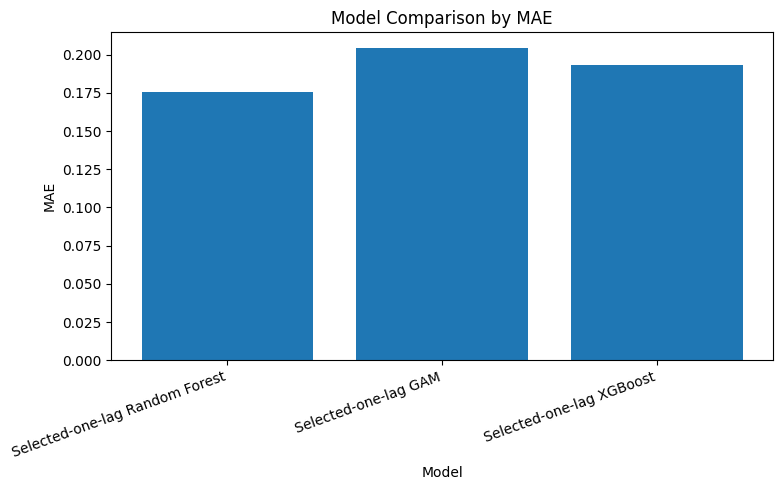

Saved: E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem1\visualizations\model_comparison_MAE.png


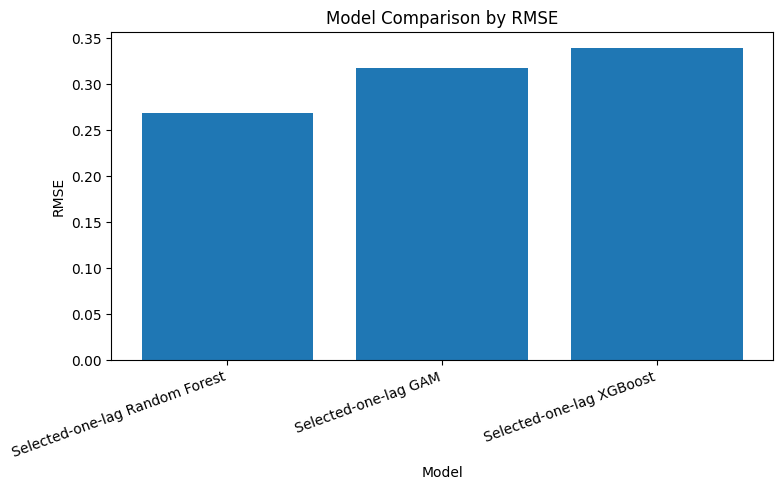

Saved: E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem1\visualizations\model_comparison_RMSE.png


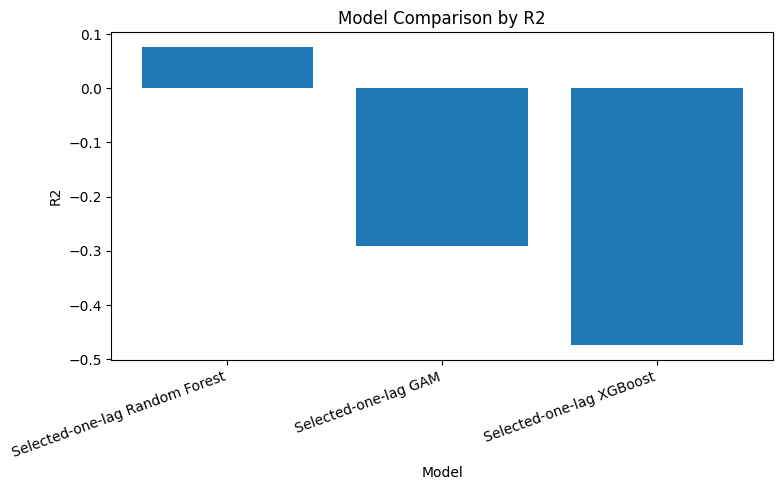

Saved: E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem1\visualizations\model_comparison_R2.png


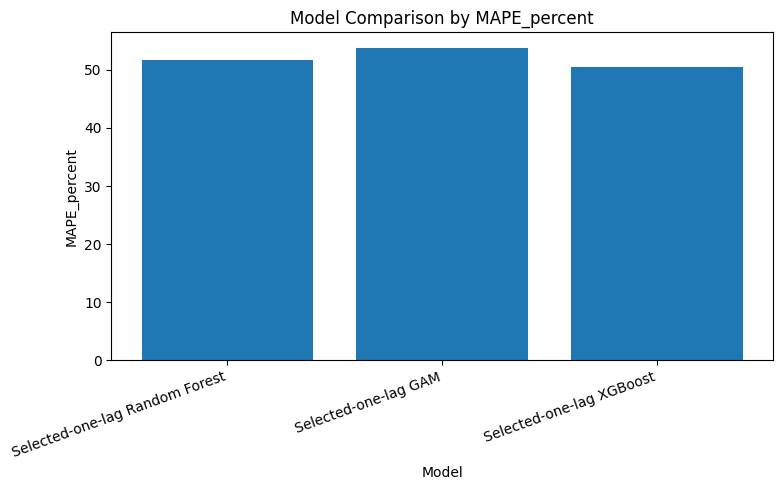

Saved: E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem1\visualizations\model_comparison_MAPE_percent.png


In [63]:
# ============================================================
# 16.1 Model metric comparison
# ============================================================

results_path = VIZ_OUTPUT_DIR / "selected_one_lag_model_results.xlsx"
results_df_viz = safe_read_excel(results_path)

if results_df_viz is not None:
    display(results_df_viz)

    metric_cols = [
        col for col in ["MAE", "RMSE", "R2", "MAPE_percent"]
        if col in results_df_viz.columns
    ]

    for metric in metric_cols:
        plt.figure(figsize=(8, 5))
        plt.bar(results_df_viz["model"], results_df_viz[metric])
        plt.xlabel("Model")
        plt.ylabel(metric)
        plt.title(f"Model Comparison by {metric}")
        plt.xticks(rotation=20, ha="right")

        fig_path = VIZ_FIG_DIR / f"model_comparison_{sanitize_filename(metric)}.png"
        save_and_show(fig_path)


### 16.2 Test-set prediction visualization

This section compares actual and predicted NTU values on the test set.


,DATETIME,OP_DATE,actual_NTU,Selected-one-lag_Random_Forest_pred,Selected-one-lag_GAM_pred,Selected-one-lag_XGBoost_pred
0,2025-12-08 21:00:00,2025-12-08,0.23,0.249579,0.363664,0.281624
1,2025-12-08 23:00:00,2025-12-08,0.23,0.294784,0.378909,0.249579
2,2025-12-09 01:00:00,2025-12-08,0.23,0.357597,0.391019,0.316824
3,2025-12-09 03:00:00,2025-12-08,0.23,0.452359,0.384162,0.347869
4,2025-12-09 05:00:00,2025-12-08,0.23,0.475762,0.398187,0.346750


Prediction columns: ['Selected-one-lag_Random_Forest_pred', 'Selected-one-lag_GAM_pred', 'Selected-one-lag_XGBoost_pred']


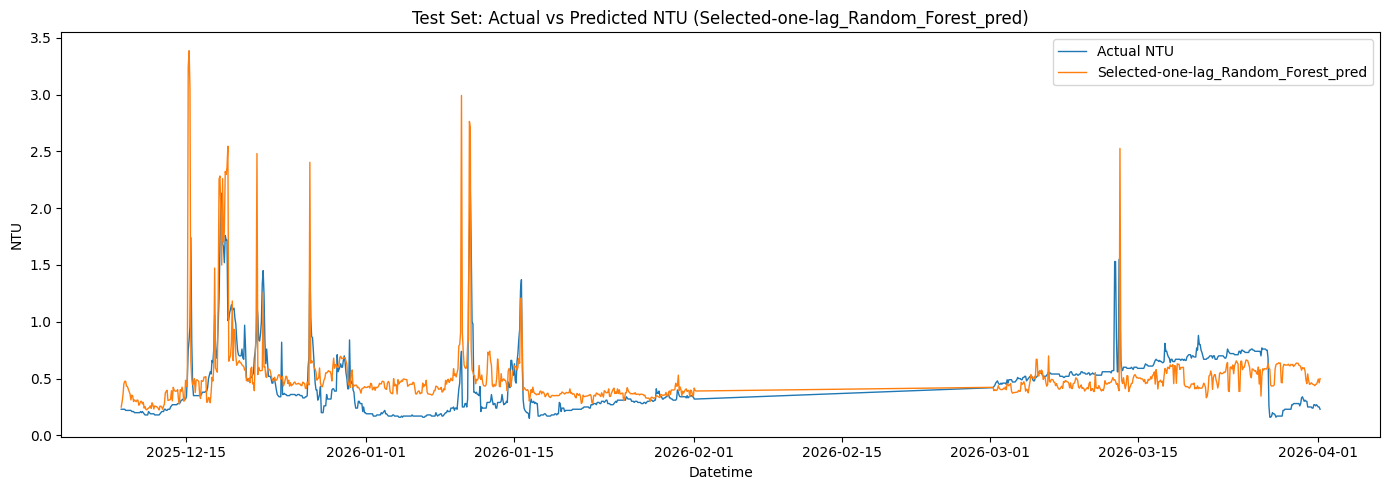

Saved: E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem1\visualizations\test_time_series_Selected-one-lag_Random_Forest_pred.png


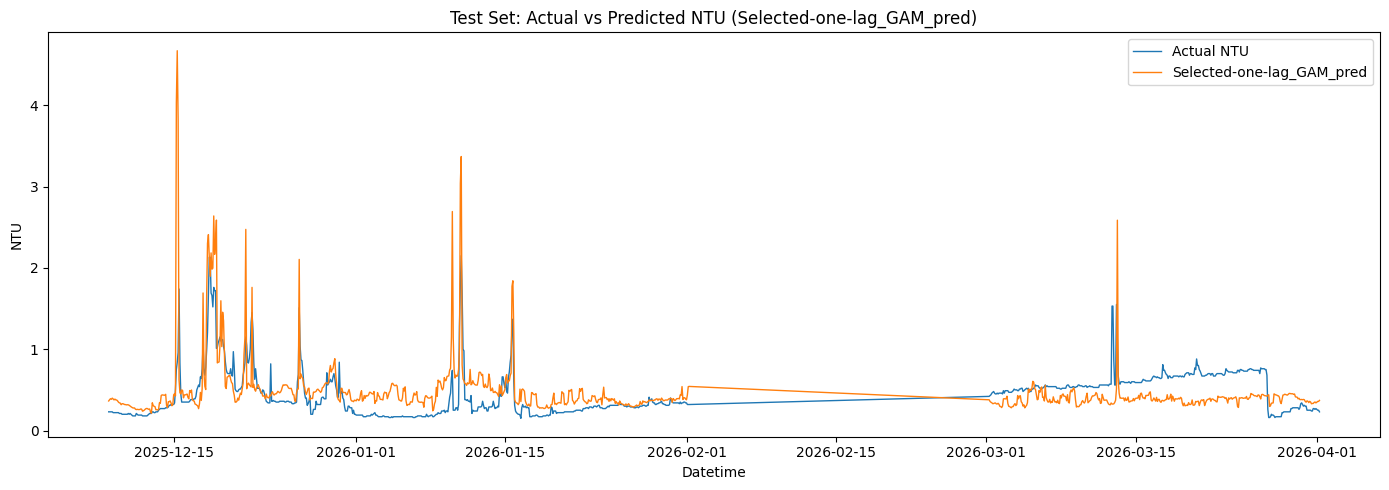

Saved: E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem1\visualizations\test_time_series_Selected-one-lag_GAM_pred.png


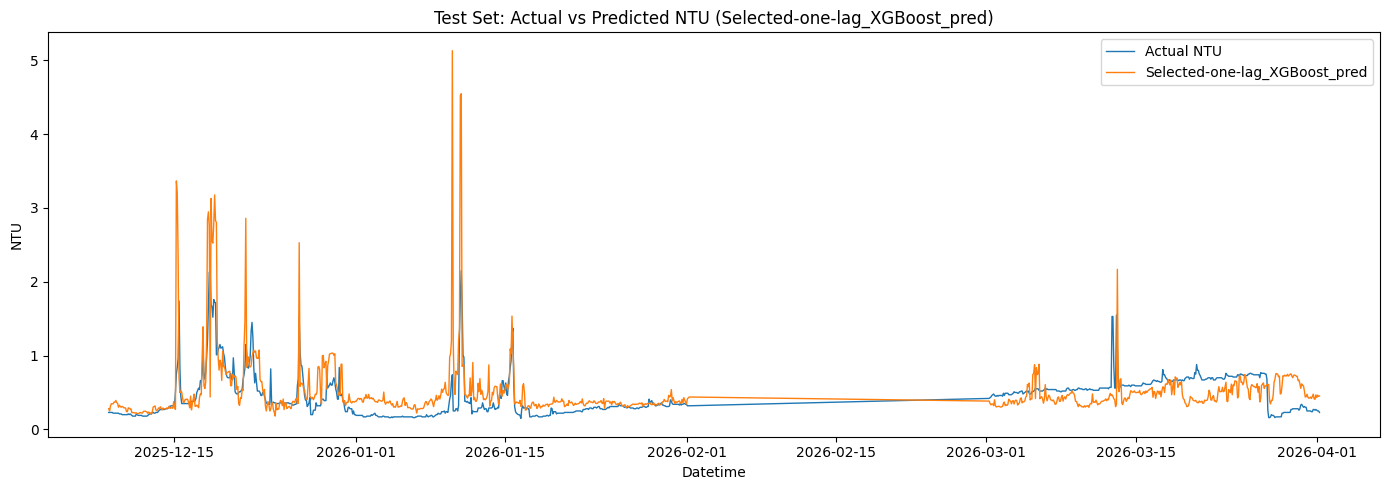

Saved: E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem1\visualizations\test_time_series_Selected-one-lag_XGBoost_pred.png


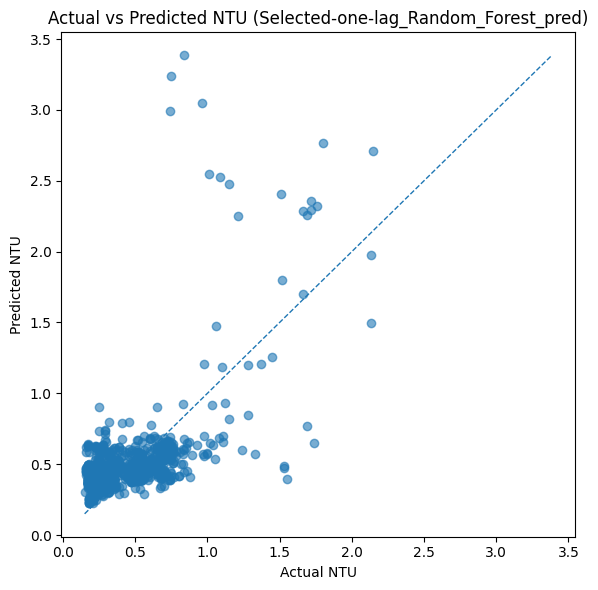

Saved: E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem1\visualizations\actual_vs_predicted_Selected-one-lag_Random_Forest_pred.png


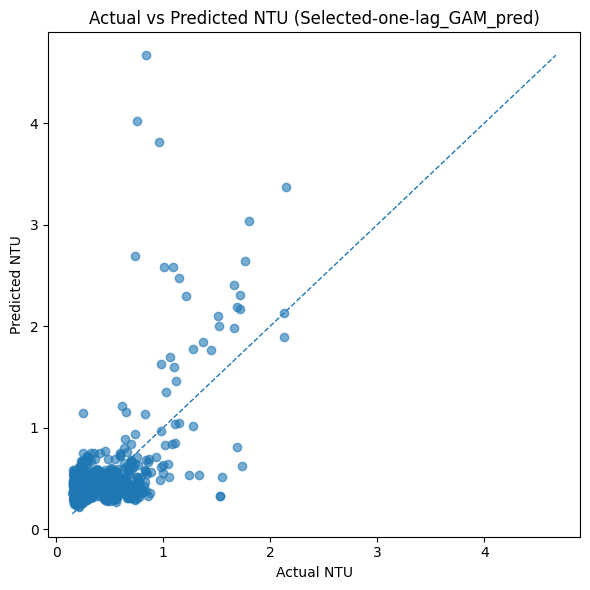

Saved: E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem1\visualizations\actual_vs_predicted_Selected-one-lag_GAM_pred.png


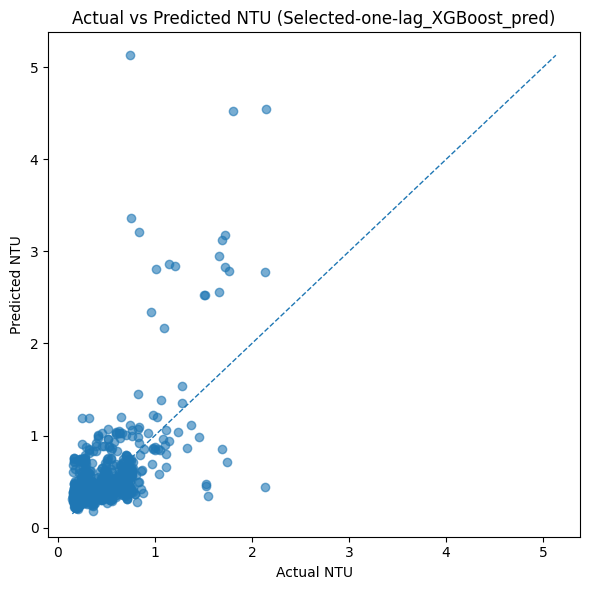

Saved: E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem1\visualizations\actual_vs_predicted_Selected-one-lag_XGBoost_pred.png


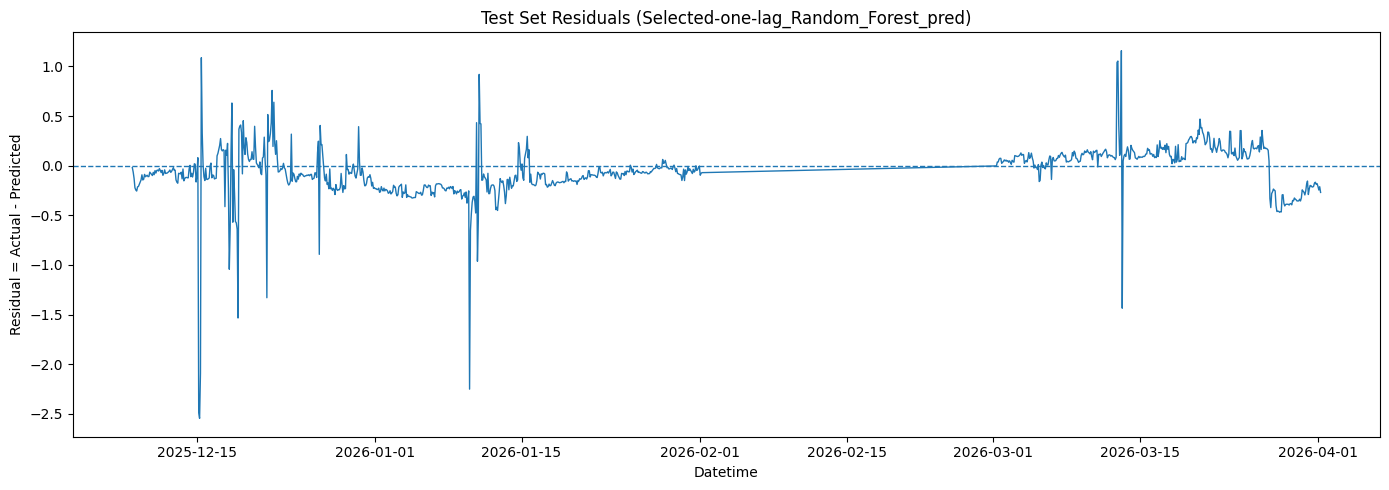

Saved: E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem1\visualizations\residual_time_series_Selected-one-lag_Random_Forest_pred.png


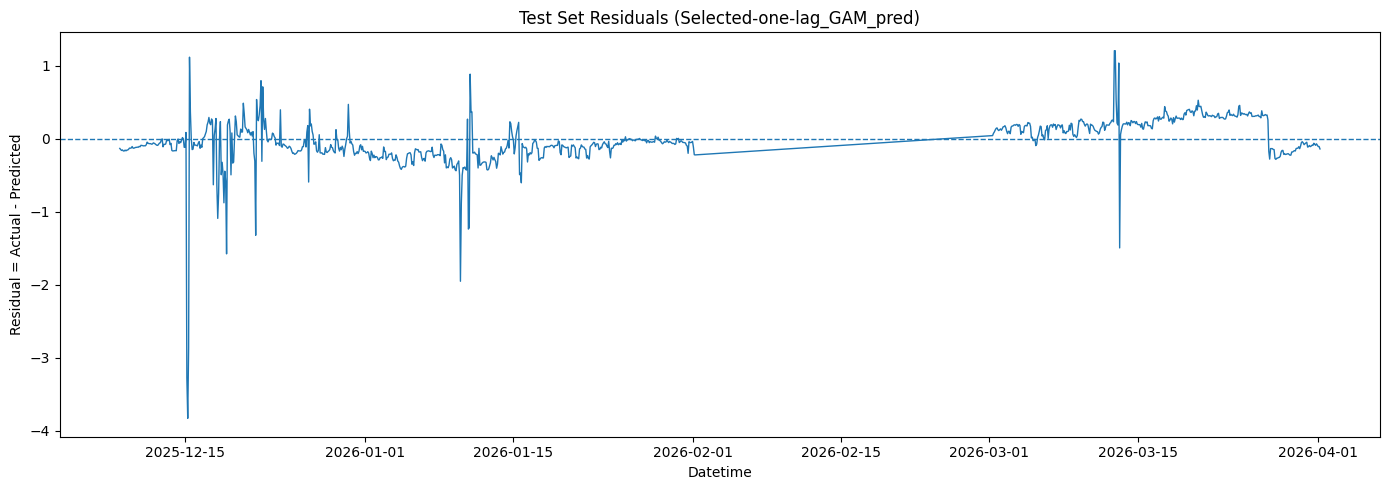

Saved: E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem1\visualizations\residual_time_series_Selected-one-lag_GAM_pred.png


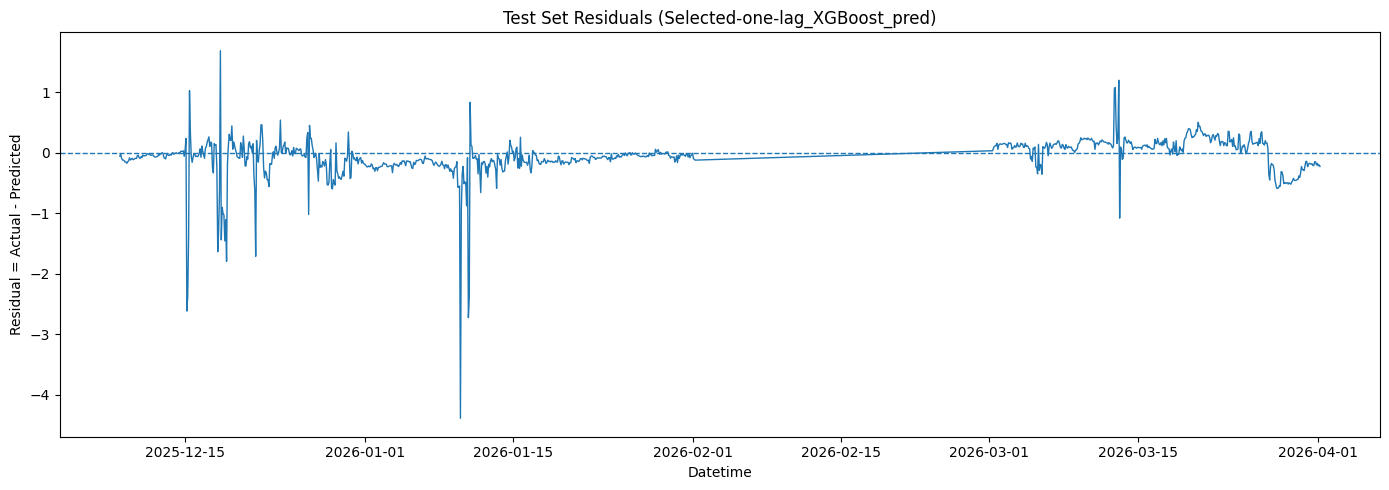

Saved: E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem1\visualizations\residual_time_series_Selected-one-lag_XGBoost_pred.png


In [64]:
# ============================================================
# 16.2 Test-set prediction visualization
# ============================================================

test_pred_path = VIZ_OUTPUT_DIR / "selected_one_lag_test_predictions.xlsx"
test_pred_df_viz = safe_read_excel(test_pred_path)

if test_pred_df_viz is not None:
    test_pred_df_viz["DATETIME"] = pd.to_datetime(test_pred_df_viz["DATETIME"], errors="coerce")
    test_pred_df_viz = test_pred_df_viz.sort_values("DATETIME").reset_index(drop=True)

    display(test_pred_df_viz.head())

    pred_cols = [
        col for col in test_pred_df_viz.columns
        if col.endswith("_pred")
    ]

    print("Prediction columns:", pred_cols)

    # Time-series plots
    for pred_col in pred_cols:
        plt.figure(figsize=(14, 5))
        plt.plot(test_pred_df_viz["DATETIME"], test_pred_df_viz["actual_NTU"], label="Actual NTU", linewidth=1)
        plt.plot(test_pred_df_viz["DATETIME"], test_pred_df_viz[pred_col], label=pred_col, linewidth=1)
        plt.xlabel("Datetime")
        plt.ylabel("NTU")
        plt.title(f"Test Set: Actual vs Predicted NTU ({pred_col})")
        plt.legend()

        fig_path = VIZ_FIG_DIR / f"test_time_series_{sanitize_filename(pred_col)}.png"
        save_and_show(fig_path)

    # Actual vs predicted scatter plots
    for pred_col in pred_cols:
        temp = test_pred_df_viz[["actual_NTU", pred_col]].dropna()
        if len(temp) == 0:
            continue

        plt.figure(figsize=(6, 6))
        plt.scatter(temp["actual_NTU"], temp[pred_col], alpha=0.6)

        min_val = min(temp["actual_NTU"].min(), temp[pred_col].min())
        max_val = max(temp["actual_NTU"].max(), temp[pred_col].max())
        plt.plot([min_val, max_val], [min_val, max_val], linestyle="--", linewidth=1)

        plt.xlabel("Actual NTU")
        plt.ylabel("Predicted NTU")
        plt.title(f"Actual vs Predicted NTU ({pred_col})")

        fig_path = VIZ_FIG_DIR / f"actual_vs_predicted_{sanitize_filename(pred_col)}.png"
        save_and_show(fig_path)

    # Residual plots
    for pred_col in pred_cols:
        temp = test_pred_df_viz[["DATETIME", "actual_NTU", pred_col]].dropna().copy()
        if len(temp) == 0:
            continue

        temp["residual"] = temp["actual_NTU"] - temp[pred_col]

        plt.figure(figsize=(14, 5))
        plt.plot(temp["DATETIME"], temp["residual"], linewidth=1)
        plt.axhline(0, linestyle="--", linewidth=1)
        plt.xlabel("Datetime")
        plt.ylabel("Residual = Actual - Predicted")
        plt.title(f"Test Set Residuals ({pred_col})")

        fig_path = VIZ_FIG_DIR / f"residual_time_series_{sanitize_filename(pred_col)}.png"
        save_and_show(fig_path)


### 16.3 Feature importance visualization

This section visualizes model-based feature importance.


,feature,importance,model
0,FILT. NTU_lag1_z,0.457392,Selected-one-lag Random Forest
1,CLR_lag0_z,0.236401,Selected-one-lag Random Forest
2,RIVER LEVEL_lag0_z,0.079347,Selected-one-lag Random Forest
3,T/W FLOW_lag1_z,0.063453,Selected-one-lag Random Forest
4,CL2_lag0_z,0.057825,Selected-one-lag Random Forest
5,R/W FLOW_lag1_z,0.056032,Selected-one-lag Random Forest
6,R/W NTU_lag0_z,0.035854,Selected-one-lag Random Forest
7,F/RIDE_lag6_z,0.006873,Selected-one-lag Random Forest
8,ALUM_lag1_z,0.006822,Selected-one-lag Random Forest
9,CLR_lag0_z,0.611275,Selected-one-lag XGBoost


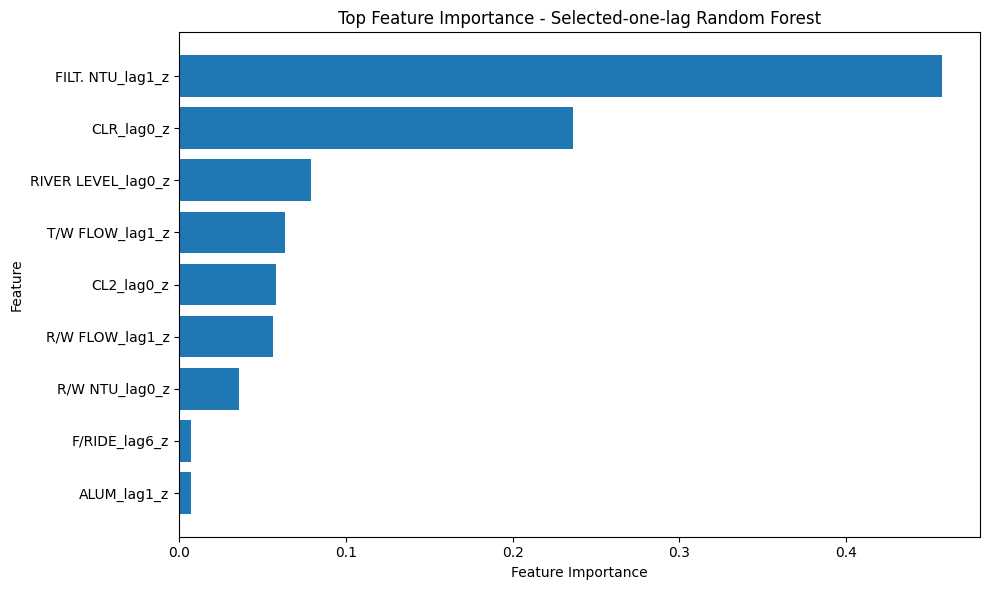

Saved: E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem1\visualizations\feature_importance_Selected-one-lag_Random_Forest.png


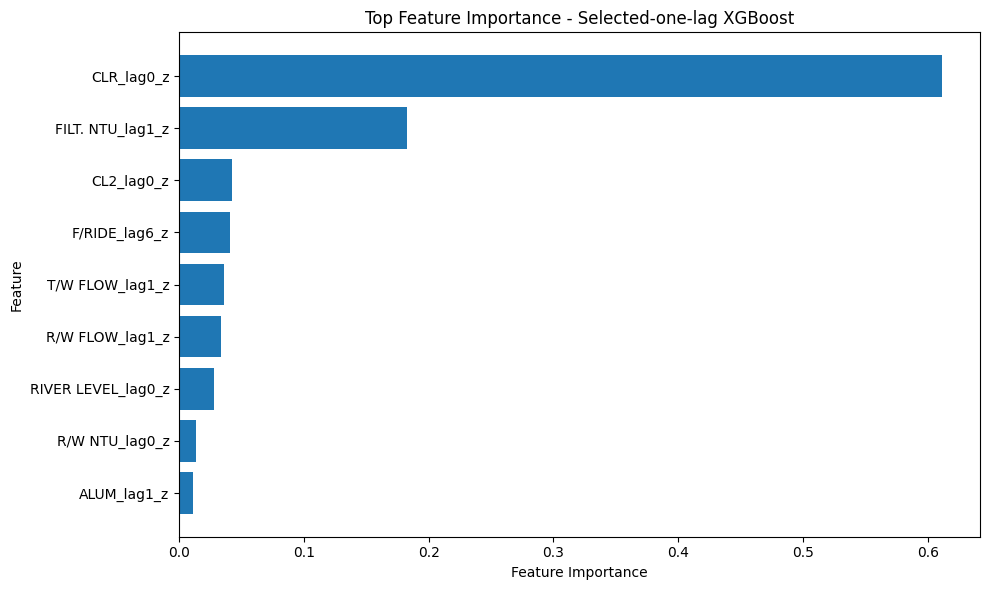

Saved: E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem1\visualizations\feature_importance_Selected-one-lag_XGBoost.png


In [65]:
# ============================================================
# 16.3 Feature importance visualization
# ============================================================

fi_path = VIZ_OUTPUT_DIR / "selected_one_lag_feature_importance.xlsx"
fi_df_viz = safe_read_excel(fi_path)

if fi_df_viz is not None and len(fi_df_viz) > 0:
    display(fi_df_viz.sort_values(["model", "importance"], ascending=[True, False]).head(30))

    for model_name, group in fi_df_viz.groupby("model"):
        top_fi = group.sort_values("importance", ascending=False).head(15)

        plt.figure(figsize=(10, 6))
        plt.barh(top_fi["feature"][::-1], top_fi["importance"][::-1])
        plt.xlabel("Feature Importance")
        plt.ylabel("Feature")
        plt.title(f"Top Feature Importance - {model_name}")

        fig_path = VIZ_FIG_DIR / f"feature_importance_{sanitize_filename(model_name)}.png"
        save_and_show(fig_path)


### 16.4 Target-date prediction visualization

This section visualizes predicted NTU values for the specified target OP_DATEs.


,DATETIME,OP_DATE,actual_NTU_if_available,Selected-one-lag_Random_Forest_final_pred,Selected-one-lag_XGBoost_final_pred
0,2026-02-01 07:00:00,2026-02-01,NaN,0.350518,0.355208
1,2026-02-01 09:00:00,2026-02-01,NaN,0.325483,0.255154
2,2026-02-01 11:00:00,2026-02-01,NaN,0.360998,0.300903
3,2026-02-01 13:00:00,2026-02-01,NaN,0.314320,0.245668
4,2026-02-01 15:00:00,2026-02-01,NaN,0.329649,0.289839
5,2026-02-01 17:00:00,2026-02-01,NaN,0.338302,0.294190
6,2026-02-01 19:00:00,2026-02-01,NaN,0.287541,0.282377
7,2026-02-01 21:00:00,2026-02-01,NaN,0.280632,0.282518
8,2026-02-01 23:00:00,2026-02-01,NaN,0.281306,0.279330
9,2026-02-02 01:00:00,2026-02-01,NaN,0.277455,0.285347


Target-date final prediction columns: ['Selected-one-lag_Random_Forest_final_pred', 'Selected-one-lag_XGBoost_final_pred']


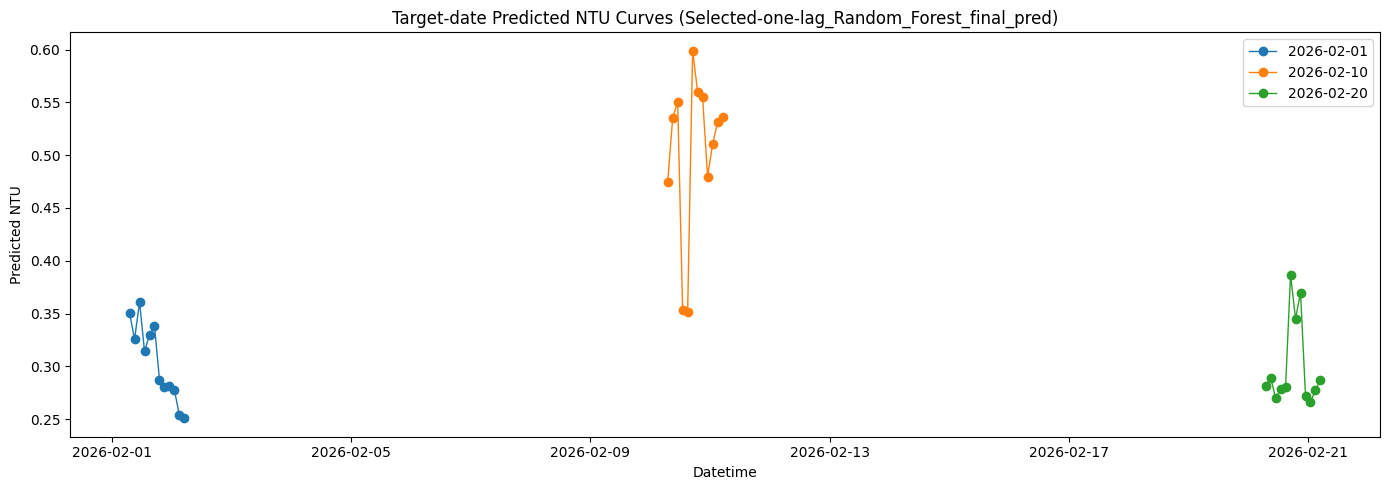

Saved: E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem1\visualizations\target_date_prediction_curves_Selected-one-lag_Random_Forest_final_pred.png


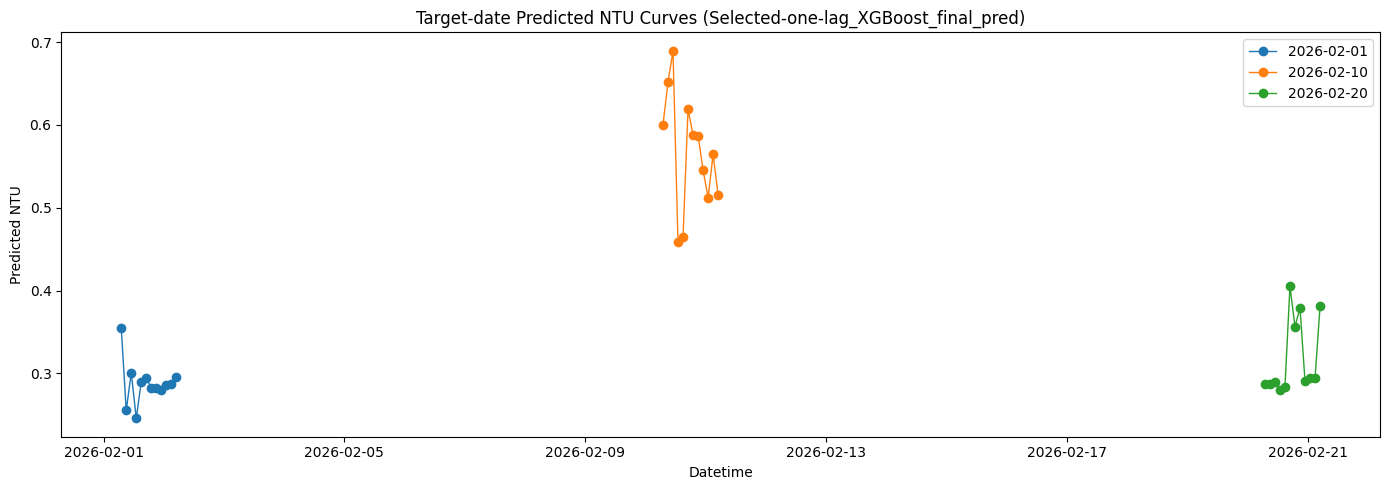

Saved: E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem1\visualizations\target_date_prediction_curves_Selected-one-lag_XGBoost_final_pred.png


,OP_DATE,n_time_points,Selected-one-lag_Random_Forest_final_pred_mean,Selected-one-lag_Random_Forest_final_pred_min,Selected-one-lag_Random_Forest_final_pred_max,Selected-one-lag_Random_Forest_final_pred_std,Selected-one-lag_XGBoost_final_pred_mean,Selected-one-lag_XGBoost_final_pred_min,Selected-one-lag_XGBoost_final_pred_max,Selected-one-lag_XGBoost_final_pred_std,actual_NTU_mean_if_available
0,2026-02-01,12,0.304217,0.250788,0.360998,0.037200,0.287732,0.245668,0.355208,0.026624,NaN
1,2026-02-10,12,0.502998,0.351554,0.598891,0.078125,0.566080,0.458050,0.689488,0.070920,NaN
2,2026-02-20,12,0.300342,0.265883,0.386391,0.041728,0.319021,0.279915,0.404967,0.046585,NaN


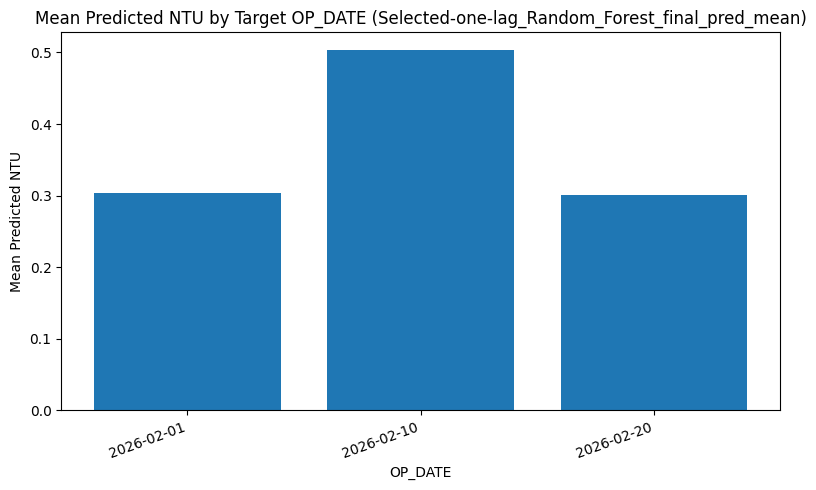

Saved: E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem1\visualizations\target_date_mean_prediction_Selected-one-lag_Random_Forest_final_pred_mean.png


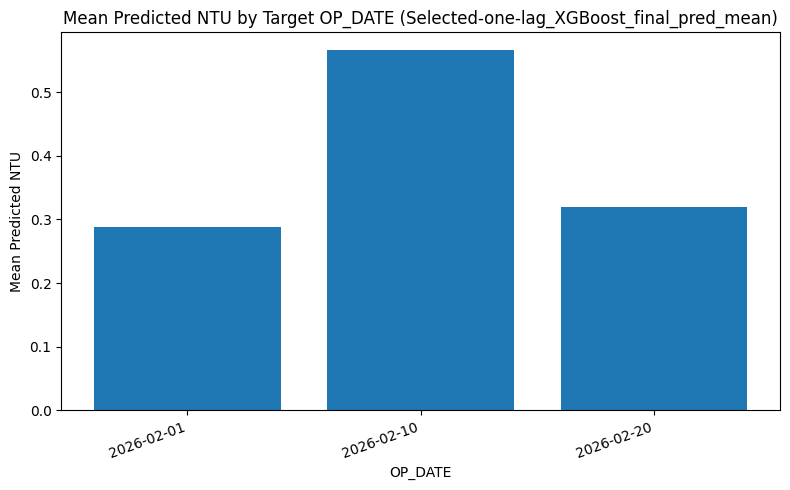

Saved: E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem1\visualizations\target_date_mean_prediction_Selected-one-lag_XGBoost_final_pred_mean.png


In [66]:
# ============================================================
# 16.4 Target-date prediction visualization
# ============================================================

target_pred_path = VIZ_OUTPUT_DIR / "target_dates_predictions.xlsx"
target_summary_path = VIZ_OUTPUT_DIR / "target_dates_prediction_summary.xlsx"

target_pred_df_viz = safe_read_excel(target_pred_path)
target_summary_df_viz = safe_read_excel(target_summary_path)

if target_pred_df_viz is not None and len(target_pred_df_viz) > 0:
    target_pred_df_viz["DATETIME"] = pd.to_datetime(target_pred_df_viz["DATETIME"], errors="coerce")
    target_pred_df_viz["OP_DATE"] = pd.to_datetime(target_pred_df_viz["OP_DATE"], errors="coerce").dt.date

    display(target_pred_df_viz.head(20))

    final_pred_cols = [
        col for col in target_pred_df_viz.columns
        if col.endswith("_final_pred")
    ]

    print("Target-date final prediction columns:", final_pred_cols)

    # One curve per final prediction column, grouped by OP_DATE
    for pred_col in final_pred_cols:
        plt.figure(figsize=(14, 5))

        for op_date, group in target_pred_df_viz.groupby("OP_DATE"):
            group = group.sort_values("DATETIME")
            plt.plot(group["DATETIME"], group[pred_col], marker="o", linewidth=1, label=str(op_date))

        plt.xlabel("Datetime")
        plt.ylabel("Predicted NTU")
        plt.title(f"Target-date Predicted NTU Curves ({pred_col})")
        plt.legend()

        fig_path = VIZ_FIG_DIR / f"target_date_prediction_curves_{sanitize_filename(pred_col)}.png"
        save_and_show(fig_path)

if target_summary_df_viz is not None and len(target_summary_df_viz) > 0:
    display(target_summary_df_viz)

    target_summary_df_viz["OP_DATE"] = pd.to_datetime(target_summary_df_viz["OP_DATE"], errors="coerce").dt.date

    mean_cols = [
        col for col in target_summary_df_viz.columns
        if col.endswith("_mean") and "_final_pred_mean" in col
    ]

    for mean_col in mean_cols:
        plt.figure(figsize=(8, 5))
        plt.bar(target_summary_df_viz["OP_DATE"].astype(str), target_summary_df_viz[mean_col])
        plt.xlabel("OP_DATE")
        plt.ylabel("Mean Predicted NTU")
        plt.title(f"Mean Predicted NTU by Target OP_DATE ({mean_col})")
        plt.xticks(rotation=20, ha="right")

        fig_path = VIZ_FIG_DIR / f"target_date_mean_prediction_{sanitize_filename(mean_col)}.png"
        save_and_show(fig_path)


## 17. Result interpretation template

After running all cells, use the generated tables and figures to write the report.

Suggested interpretation structure:

```text
1. Compare selected-one-lag RF and XGBoost using MAE, RMSE, and R².
2. Select the model with the lowest test RMSE as the main predictive model.
3. Use feature importance to explain the dominant factors.
4. Use target_dates_predictions.xlsx and target_dates_prediction_summary.xlsx to report the three required prediction days.
5. Avoid claiming that the model is highly accurate if R² is only slightly positive or still negative.
```
